# Data Download


## Copy datasets from OOINET to localhost.


The data order is manual. Resulting links are placed in `~/argosy/download_link_list.txt`, one URL per line, for example:


```
https://downloads.oceanobservatories.org/async_results/kilroy1618@gmail.com/20260207T235914738Z-RS01SBPS-SF01A-2A-CTDPFA102-streamed-ctdpf_sbe43_sample
```


Here is what the three cells in this notebook do:


- First cell: From links in `~/argosy/download_link_list.txt` download source data files 
    - > corresponding localhost folders `~/ooi/ooinet/rca/SlopeBase/{scalar | vector}/<yyyy>_<instrum>
- Second cell: Scan for redundant source data files, step one
    - Creates a bash script in `~/argosy` that deletes superfluous files
- Third cell: Scan remaining files for "minimum cover" files
    - This is the minimum number of files that cover the entirety of available time
    - Creates a bash script again that deletes superfluous files

In [2]:
#!/usr/bin/env python
# coding: utf-8

# # Data Download
#
#
# This notebook copies datasets from OOINET to localhost.
#
#
# The data order is manual.
# The resulting links are placed in the text file `~/argosy/download_link_list.txt`: One URL per line:
#
#
# ```
# https://downloads.oceanobservatories.org/async_results/kilroy1618@gmail.com/20260207T235914738Z-RS01SBPS-SF01A-2A-CTDPFA102-streamed-ctdpf_sbe43_sample
# ```
#
# We want the code in the cell below to read this file and go to each link in succession,
# downloading the data to a corresponding localhost folder.

# In[8]:


import requests
from pathlib import Path
from bs4 import BeautifulSoup
import re

def parse_year_from_filename(filename):
    """Extract year from NetCDF filename."""
    pattern = r'_(\d{4})\d{2}\d{2}T\d{6}\.\d+-\d{8}T\d{6}\.\d+\.nc$'
    match = re.search(pattern, filename)
    if match:
        return int(match.group(1))
    return None

def is_file_complete(filepath):
    """Check if file exists and is non-zero size."""
    if not filepath.exists():
        return False
    return filepath.stat().st_size > 0

def download_file(url, destination):
    """Download a file from URL to destination."""
    temp_file = destination.with_suffix('.tmp')
    try:
        response = requests.get(url, stream=True, timeout=300)
        response.raise_for_status()

        with open(temp_file, 'wb') as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)

        temp_file.rename(destination)
        return True
    except Exception as e:
        print(f"    Error: {e}")
        if temp_file.exists():
            temp_file.unlink()
        return False

def bulk_download(instrument="ctd", ooi_instrument="CTDPF"):
    """Bulk download instrument files from URL list with restart tolerance."""

    print(f"Running bulk_download for instrument type = {instrument} (OOI: {ooi_instrument})")

    # Read URL list
    url_list_file = Path("~/argosy/download_link_list.txt").expanduser()
    if not url_list_file.exists():
        print(f"File not found: {url_list_file}")
        return

    with open(url_list_file, 'r') as f:
        urls = [line.strip() for line in f if line.strip()]

    print(f"Found {len(urls)} URLs to process\n")

    # Base folder for all instrument/year source data
    base_folder = Path("~/ooi/ooinet/rca/SlopeBase/scalar").expanduser()

    if not base_folder.exists():
        print(f"Base folder does not exist: {base_folder}")
        return

    # Create year folders as needed
    for year in range(2014, 2027):
        year_folder = base_folder / f"{year}_{instrument}"
        year_folder.mkdir(exist_ok=True)

    total_downloaded = 0
    total_skipped    = 0
    total_complete   = 0

    for url_idx, url in enumerate(urls, 1):
        print(f"=== URL {url_idx}/{len(urls)} ===")
        print(f"{url}")

        try:
            response = requests.get(url, timeout=30)
            response.raise_for_status()

            soup  = BeautifulSoup(response.text, 'html.parser')
            links = soup.find_all('a')

            nc_files = [
                link.get('href', '') for link in links
                if link.get('href', '').endswith('.nc')
                and not link.get('href', '').endswith('.ncml')
                and ooi_instrument in link.get('href', '')
            ]

            already_downloaded = 0
            to_download = []

            for filename in nc_files:
                year = parse_year_from_filename(filename)
                if year is None:
                    continue
                dest_file = base_folder / f"{year}_{instrument}" / filename
                if is_file_complete(dest_file):
                    already_downloaded += 1
                else:
                    to_download.append((filename, year))

            print(f"  Total .nc files:       {len(nc_files)}")
            print(f"  Already downloaded:    {already_downloaded}")
            print(f"  Remaining to download: {len(to_download)}")

            total_complete += already_downloaded

            if not to_download:
                print(f"  All files complete, skipping\n")
                continue

            for file_idx, (filename, year) in enumerate(to_download, 1):
                dest_file = base_folder / f"{year}_{instrument}" / filename
                file_url  = url.rstrip('/') + '/' + filename
                print(f"  [{file_idx}/{len(to_download)}] {filename} -> {year}_{instrument}/")

                if download_file(file_url, dest_file):
                    total_downloaded += 1
                    print(f"    Complete: {dest_file.stat().st_size / (1024*1024):.1f} MB")
                else:
                    total_skipped += 1

            print()

        except Exception as e:
            print(f"  Error processing URL: {e}\n")
            continue

    print(f"=== Download Summary ===")
    print(f"Files already complete:  {total_complete}")
    print(f"Files newly downloaded:  {total_downloaded}")
    print(f"Files failed/skipped:    {total_skipped}")

    print("\nTotal files by year:")
    for year in range(2014, 2027):
        year_folder = base_folder / f"{year}_{instrument}"
        if year_folder.exists():
            count = len(list(year_folder.glob("*.nc")))
            if count > 0:
                print(f"  {year}: {count} files")


# Instrument key -> OOI instrument code mapping (from Sensor Table):
#   ctd   -> CTDPF
#   flor  -> FLORT
#   ph    -> PHSEN
#   pco2  -> PCO2W
#   nitr  -> NUTNR
#   par   -> PARAD
#   vel   -> VELPT
#   irr   -> SPKIR
#   oa/ba -> OPTAA

# Run the bulk download - uncomment as needed:
bulk_download("ctd",  "CTDPF")
# bulk_download("flor", "FLORT")
# bulk_download("ph",   "PHSEN")
# bulk_download("pco2", "PCO2W")
# bulk_download("nitr", "NUTNR")
# bulk_download("par",  "PARAD")
# bulk_download("vel",  "VELPT")
# bulk_download("irr",  "SPKIR")


Running bulk_download for instrument type = ctd (OOI: CTDPF)
Found 3 URLs to process

=== URL 1/3 ===
https://downloads.oceanobservatories.org/async_results/kilroy1618@gmail.com/20260302T160213452Z-RS01SBPS-SF01A-2D-PHSENA101-streamed-phsen_data_record
  Total .nc files:       31
  Already downloaded:    2
  Remaining to download: 29
  [1/29] deployment0001_RS01SBPS-SF01A-2A-CTDPFA102-streamed-ctdpf_sbe43_sample_20141231T235959.533995-20150424T172450.573911.nc -> 2014_ctd/
    Complete: 644.2 MB
  [2/29] deployment0001_RS01SBPS-SF01A-2A-CTDPFA102-streamed-ctdpf_sbe43_sample_20150424T172451.574121-20150705T235959.089334.nc -> 2015_ctd/
    Complete: 422.9 MB
  [3/29] deployment0002_RS01SBPS-SF01A-2A-CTDPFA102-streamed-ctdpf_sbe43_sample_20150708T220539.700577-20151107T011756.232005.nc -> 2015_ctd/
    Complete: 650.3 MB
  [4/29] deployment0002_RS01SBPS-SF01A-2A-CTDPFA102-streamed-ctdpf_sbe43_sample_20151107T011757.231076-20160203T075108.287602.nc -> 2015_ctd/
    Complete: 535.7 MB
  [5

CTD File Overlap Audit
Total CTD files found: 40
Overlapping file pairs: 48

Overlap details:

  A: deployment0001_RS01SBPS-SF01A-2A-CTDPFA102-streamed-ctdpf_sbe43_sample_20141231T235959.533995-20150518T000000.646750.nc
  B: deployment0001_RS01SBPS-SF01A-2A-CTDPFA102-streamed-ctdpf_sbe43_sample_20150424T172451.574121-20150705T235959.089334.nc
  Overlap: 2015-04-24 to 2015-05-18 (23.3 days)

  A: deployment0002_RS01SBPS-SF01A-2A-CTDPFA102-streamed-ctdpf_sbe43_sample_20150708T220539.700577-20151130T000000.854900.nc
  B: deployment0002_RS01SBPS-SF01A-2A-CTDPFA102-streamed-ctdpf_sbe43_sample_20151107T011757.231076-20160203T075108.287602.nc
  Overlap: 2015-11-07 to 2015-11-30 (22.9 days)

  A: deployment0002_RS01SBPS-SF01A-2A-CTDPFA102-streamed-ctdpf_sbe43_sample_20150708T220539.700577-20151130T000000.854900.nc
  B: deployment0002_RS01SBPS-SF01A-2A-CTDPFA102-streamed-ctdpf_sbe43_sample_20151112T235959.387746-20160301T180000.653717.nc
  Overlap: 2015-11-12 to 2015-11-30 (17.0 days)

  A: dep

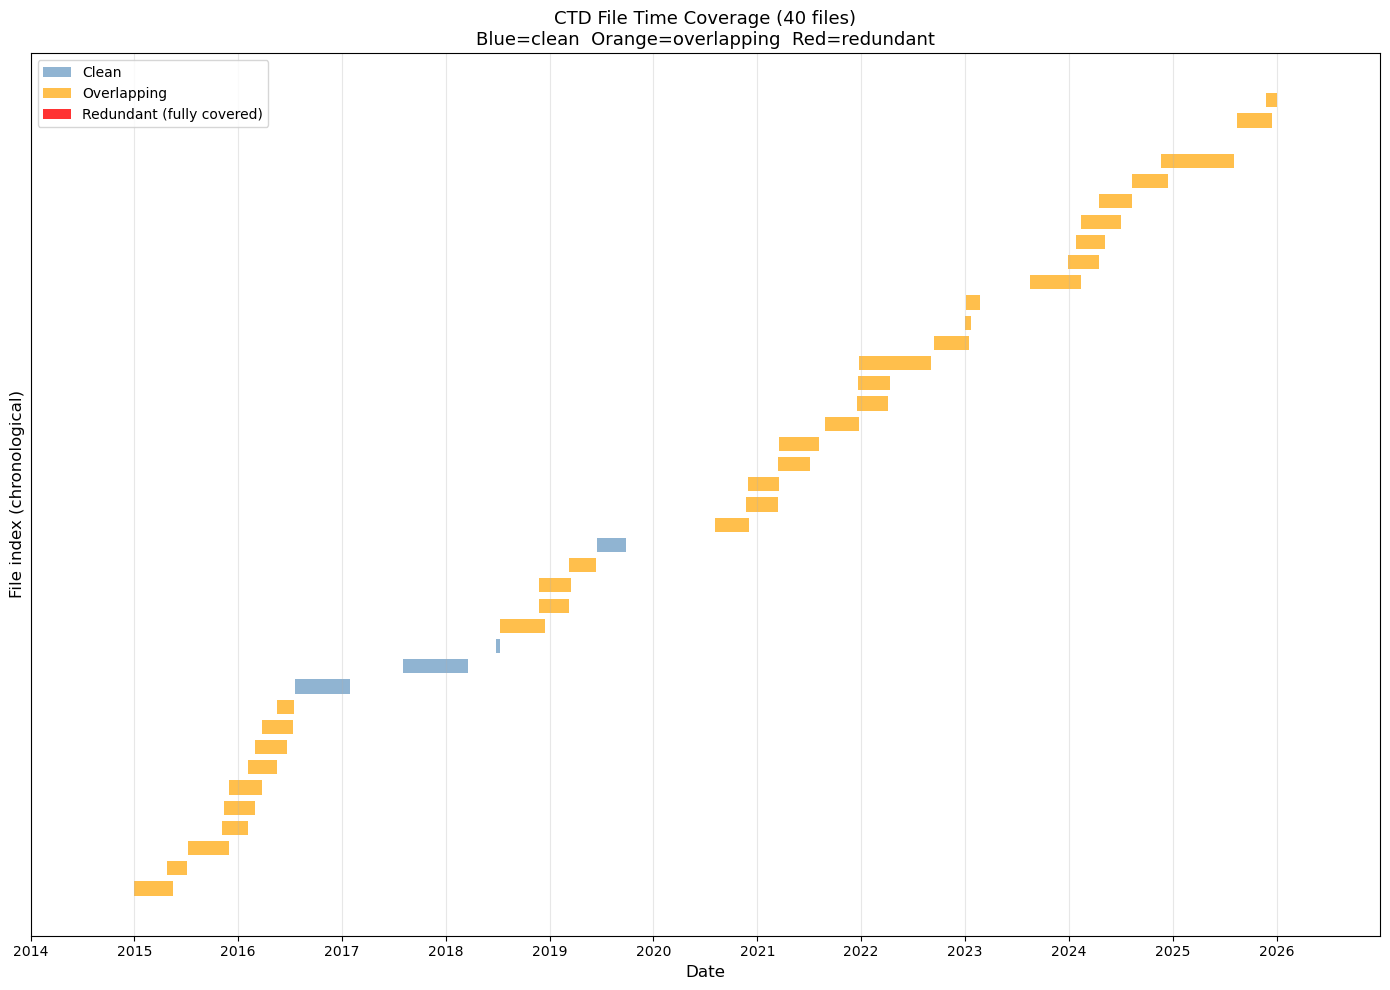

Plot saved to ~/argosy/ctd_coverage.png


In [6]:
# Jupyter cell: CTD file overlap audit
# Identifies redundant CTD files and plots time coverage bars
# This is part one: It identifies files that are entirely overlapped by other files and adds them
#   to a deletion script. After running this script there should be no more red files; just yellow
#   and possibly blue. See the next cell for a further cleaning step.

import re
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from datetime import datetime

print("CTD File Overlap Audit")
print("=" * 60)

BASE = Path("~/ooi/ooinet/rca/SlopeBase/scalar").expanduser()
YEARS = range(2014, 2027)

# --- Parse time range from filename ---
def parse_time_range(filename):
    """Extract start and end datetime from CTD filename."""
    pattern = r'_(\d{8}T\d{6})\.\d+-(\d{8}T\d{6})\.\d+\.nc$'
    match = re.search(pattern, filename)
    if not match:
        return None, None
    fmt = "%Y%m%dT%H%M%S"
    try:
        start = datetime.strptime(match.group(1), fmt)
        end   = datetime.strptime(match.group(2), fmt)
        return start, end
    except ValueError:
        return None, None

# --- Collect all CTD files ---
all_files = []
for year in YEARS:
    folder = BASE / f"{year}_ctd"
    if not folder.exists():
        continue
    for f in sorted(folder.glob("*.nc")):
        start, end = parse_time_range(f.name)
        if start and end:
            all_files.append({'name': f.name, 'path': f, 'start': start, 'end': end, 'year': year})

print(f"Total CTD files found: {len(all_files)}")

# --- Detect overlaps ---
# Sort by start time
all_files.sort(key=lambda x: x['start'])

overlaps = []
for i in range(len(all_files)):
    for j in range(i + 1, len(all_files)):
        a = all_files[i]
        b = all_files[j]
        # If b starts after a ends, no overlap possible for any later j
        if b['start'] >= a['end']:
            break
        # Overlap: b starts before a ends
        overlap_start = max(a['start'], b['start'])
        overlap_end   = min(a['end'],   b['end'])
        overlap_days  = (overlap_end - overlap_start).total_seconds() / 86400
        overlaps.append({
            'file_a': a['name'],
            'file_b': b['name'],
            'overlap_start': overlap_start,
            'overlap_end':   overlap_end,
            'overlap_days':  overlap_days
        })

print(f"Overlapping file pairs: {len(overlaps)}")

if overlaps:
    print(f"\nOverlap details:")
    for ov in overlaps:
        print(f"\n  A: {ov['file_a']}")
        print(f"  B: {ov['file_b']}")
        print(f"  Overlap: {ov['overlap_start'].date()} to {ov['overlap_end'].date()} ({ov['overlap_days']:.1f} days)")

# --- Identify redundant files ---
# A file is redundant if its entire time range is covered by another file
redundant = []
for i, f in enumerate(all_files):
    for j, g in enumerate(all_files):
        if i == j:
            continue
        # f is fully contained within g
        if g['start'] <= f['start'] and g['end'] >= f['end'] and f['name'] != g['name']:
            redundant.append({'redundant': f, 'covered_by': g})
            break

print(f"\nFully redundant files (entirely covered by another): {len(redundant)}")
for r in redundant:
    print(f"  REDUNDANT: {r['redundant']['name']}")
    print(f"  COVERED BY: {r['covered_by']['name']}")

# --- Strategy recommendation ---
print(f"\n{'=' * 60}")
print("STRATEGY RECOMMENDATION")
print(f"{'=' * 60}")

script_path = Path("~/argosy/delete_overlaps.sh").expanduser()

if len(overlaps) == 0:
    print("No overlaps detected - CTD files appear clean.")
    if script_path.exists():
        script_path.unlink()
        print("(Removed stale delete_overlaps.sh)")
elif len(redundant) > 0:
    total_size = sum(r['redundant']['path'].stat().st_size for r in redundant) / (1024*1024)
    print(f"Delete {len(redundant)} fully redundant files ({total_size:.1f} MB recoverable)")
    print("For partial overlaps: Keep the file with the longer time span.")

    # Write shell script
    lines = [
        "#!/bin/bash",
        "# Auto-generated by ctd_overlap_audit.py",
        "# Deletes fully redundant CTD files (time range entirely covered by another file)",
        "",
    ]
    for r in redundant:
        lines.append(f"# Covered by: {r['covered_by']['name']}")
        lines.append(f"rm \"{r['redundant']['path']}\"")
        lines.append("")

    script_path.write_text("\n".join(lines))
    script_path.chmod(0o755)
    print(f"\nDeletion script written to: {script_path}")
    print(f"Review and run with:  bash {script_path}")
else:
    print(f"{len(overlaps)} partial overlaps found but no fully redundant files.")
    print("For each overlapping pair: Keep the file with the longer time span.")
    print("Partial overlaps may require trimming rather than deletion.")

# --- Plot: time coverage bars ---
print(f"\nGenerating coverage plot...")

fig, ax = plt.subplots(figsize=(14, max(4, len(all_files) * 0.25)))

# Color: red if redundant, orange if overlapping, blue otherwise
redundant_names = {r['redundant']['name'] for r in redundant}
overlap_names   = {ov['file_a'] for ov in overlaps} | {ov['file_b'] for ov in overlaps}

for i, f in enumerate(all_files):
    if f['name'] in redundant_names:
        color = 'red'
        alpha = 0.8
    elif f['name'] in overlap_names:
        color = 'orange'
        alpha = 0.7
    else:
        color = 'steelblue'
        alpha = 0.6

    ax.barh(i, (f['end'] - f['start']).total_seconds() / 86400,
            left=mdates.date2num(f['start']),
            height=0.7, color=color, alpha=alpha, edgecolor='none')

# Format x-axis as dates
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('File index (chronological)', fontsize=12)
ax.set_title(f'CTD File Time Coverage ({len(all_files)} files)\n'
             f'Blue=clean  Orange=overlapping  Red=redundant', fontsize=13)
ax.set_xlim(mdates.date2num(datetime(2014, 1, 1)),
            mdates.date2num(datetime(2026, 12, 31)))
ax.grid(True, axis='x', alpha=0.3)
ax.set_yticks([])

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue', alpha=0.6, label='Clean'),
    Patch(facecolor='orange',    alpha=0.7, label='Overlapping'),
    Patch(facecolor='red',       alpha=0.8, label='Redundant (fully covered)'),
]
ax.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.savefig(Path("~/argosy/ctd_coverage.png").expanduser(), dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to ~/argosy/ctd_coverage.png")

CTD Minimum Cover Analysis
Total CTD files: 29
Files needed for full coverage: 29
Files deletable without losing coverage: 0

No deletable files found - set is already minimal.


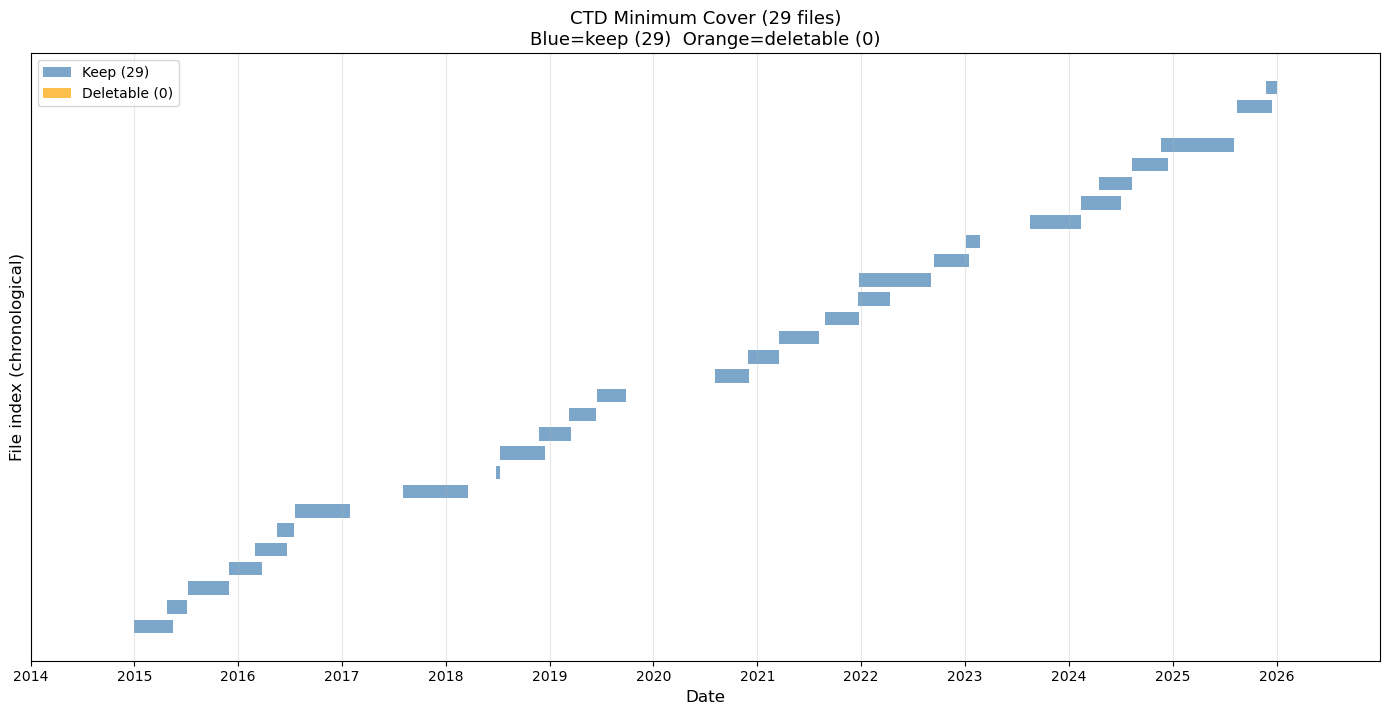

Plot saved to /home/rob/argosy/ctd_minimum_cover.png


In [8]:
# Jupyter cell: CTD minimum cover analysis
# Finds the minimal set of files that preserves full time coverage,
# then generates a deletion script for all others.

import re
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from datetime import datetime

print("CTD Minimum Cover Analysis")
print("=" * 60)

BASE = Path("~/ooi/ooinet/rca/SlopeBase/scalar").expanduser()
YEARS = range(2014, 2027)

def parse_time_range(filename):
    pattern = r'_(\d{8}T\d{6})\.\d+-(\d{8}T\d{6})\.\d+\.nc$'
    match = re.search(pattern, filename)
    if not match:
        return None, None
    fmt = "%Y%m%dT%H%M%S"
    try:
        return datetime.strptime(match.group(1), fmt), datetime.strptime(match.group(2), fmt)
    except ValueError:
        return None, None

# --- Collect all CTD files ---
all_files = []
for year in YEARS:
    folder = BASE / f"{year}_ctd"
    if not folder.exists():
        continue
    for f in sorted(folder.glob("*.nc")):
        start, end = parse_time_range(f.name)
        if start and end:
            all_files.append({'name': f.name, 'path': f, 'start': start, 'end': end})

all_files.sort(key=lambda x: x['start'])
print(f"Total CTD files: {len(all_files)}")

# --- Greedy interval cover algorithm ---
# At each step: among all files whose start <= current frontier,
# pick the one with the furthest end time. Advance frontier. Repeat.
# This is the classic greedy minimum interval cover and is optimal.

def minimum_cover(files):
    """
    Returns the minimal subset of files that covers the same
    total time span as all files combined, with no gaps.
    Files must be sorted by start time.
    """
    if not files:
        return [], []

    keep = []
    deletable = []

    # Work through the timeline left to right
    frontier = files[0]['start']   # earliest start
    end_of_all = max(f['end'] for f in files)

    remaining = list(files)

    while frontier < end_of_all:
        # Candidates: all files that start at or before the current frontier
        candidates = [f for f in remaining if f['start'] <= frontier]

        if not candidates:
            # Gap in coverage - advance frontier to next file start
            next_file = min(remaining, key=lambda x: x['start'])
            frontier = next_file['start']
            candidates = [next_file]

        # Pick the candidate with the furthest end time
        best = max(candidates, key=lambda x: x['end'])
        keep.append(best)
        remaining.remove(best)

        # Everything else that started before or at frontier and ends
        # before or at best.end is now redundant given best
        newly_redundant = [
            f for f in remaining
            if f['start'] <= frontier and f['end'] <= best['end']
        ]
        for f in newly_redundant:
            deletable.append(f)
            remaining.remove(f)

        frontier = best['end']

    # Any remaining files not yet classified
    for f in remaining:
        # Check if covered by the keep set
        covered = any(k['start'] <= f['start'] and k['end'] >= f['end'] for k in keep)
        if covered:
            deletable.append(f)
        else:
            keep.append(f)

    return keep, deletable

keep, deletable = minimum_cover(all_files)

print(f"Files needed for full coverage: {len(keep)}")
print(f"Files deletable without losing coverage: {len(deletable)}")

if deletable:
    total_size = sum(f['path'].stat().st_size for f in deletable) / (1024*1024)
    print(f"Recoverable space: {total_size:.1f} MB")

# --- Write deletion script ---
script_path = Path("~/argosy/delete_overlaps2.sh").expanduser()

if deletable:
    lines = [
        "#!/bin/bash",
        "# Auto-generated by ctd_minimum_cover.py",
        "# Deletes CTD files whose coverage is fully provided by other files.",
        "# The remaining files preserve complete time coverage.",
        "",
    ]
    for f in sorted(deletable, key=lambda x: x['start']):
        lines.append(f"rm \"{f['path']}\"")

    script_path.write_text("\n".join(lines))
    script_path.chmod(0o755)
    print(f"\nDeletion script written to: {script_path}")
    print(f"Review and run with:  bash {script_path}")
else:
    print("\nNo deletable files found - set is already minimal.")

# --- Plot ---
fig, ax = plt.subplots(figsize=(14, max(4, len(all_files) * 0.25)))

keep_names = {f['name'] for f in keep}

for i, f in enumerate(all_files):
    color = 'steelblue' if f['name'] in keep_names else 'orange'
    alpha = 0.7
    ax.barh(i,
            (f['end'] - f['start']).total_seconds() / 86400,
            left=mdates.date2num(f['start']),
            height=0.7, color=color, alpha=alpha, edgecolor='none')

ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('File index (chronological)', fontsize=12)
ax.set_title(f'CTD Minimum Cover ({len(all_files)} files)\n'
             f'Blue=keep ({len(keep)})  Orange=deletable ({len(deletable)})', fontsize=13)
ax.set_xlim(mdates.date2num(datetime(2014, 1, 1)),
            mdates.date2num(datetime(2026, 12, 31)))
ax.grid(True, axis='x', alpha=0.3)
ax.set_yticks([])

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='steelblue', alpha=0.7, label=f'Keep ({len(keep)})'),
    Patch(facecolor='orange',    alpha=0.7, label=f'Deletable ({len(deletable)})'),
], loc='upper left')

plt.tight_layout()
plot_path = Path("~/argosy/ctd_minimum_cover.png").expanduser()
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Plot saved to {plot_path}")
